# Leave-One-Out Cross-Validation (LOOCV)

## Overview

LOOCV is k-fold CV taken to its extreme: k = n. Each observation serves as the validation set exactly once, trained on all remaining n−1 observations.

**Properties:**

| Property | LOOCV | k-fold (k=10) |
|---|---|---|
| **Bias** | Nearly unbiased | Small downward bias (trains on less data) |
| **Variance** | High (estimates are correlated) | Lower |
| **Computation** | O(n) model fits | O(k) model fits |
| **Practical** | Only for fast models or analytic shortcuts | General purpose |

**When LOOCV is appropriate:**
- Small datasets (n < 50) where k-fold CV wastes too much training data
- Linear models where the LOOCV estimate has an analytic shortcut (no refitting)
- When nearly unbiased error estimation is critical and compute is available

**Analytic shortcut for linear models:** For OLS, the LOOCV MSE can be computed without refitting n models:
$$\text{LOOCV MSE} = \frac{1}{n}\sum_{i=1}^n \left(\frac{e_i}{1 - h_{ii}}\right)^2$$
where $e_i$ is the residual and $h_{ii}$ is the leverage of observation $i$.

---

## Setup

In [1]:
library(tidyverse)
library(ggplot2)
library(rsample)
library(parsnip)
library(workflows)
library(recipes)
library(tune)
library(yardstick)
library(patchwork)

set.seed(42)

# Small dataset where LOOCV is appropriate
n_small <- 40
loocv_data <- tibble(
  nitrate    = rnorm(n_small, 3, 1.2),
  water_qual = rnorm(n_small, 6, 1.5),
  elevation  = rnorm(n_small, 200, 80),
  richness   = round(25 - 2.5*nitrate + 1.5*water_qual + rnorm(n_small, 0, 3))
)

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'rsample' was built under R version 4.4.3"
Warning message:
"package 'parsnip' was built under R version 4.

---

## Analytic LOOCV for Linear Models (No Refitting)

Analytic LOOCV RMSE:    2.6648
Brute-force LOOCV RMSE: 2.6648  (should match)


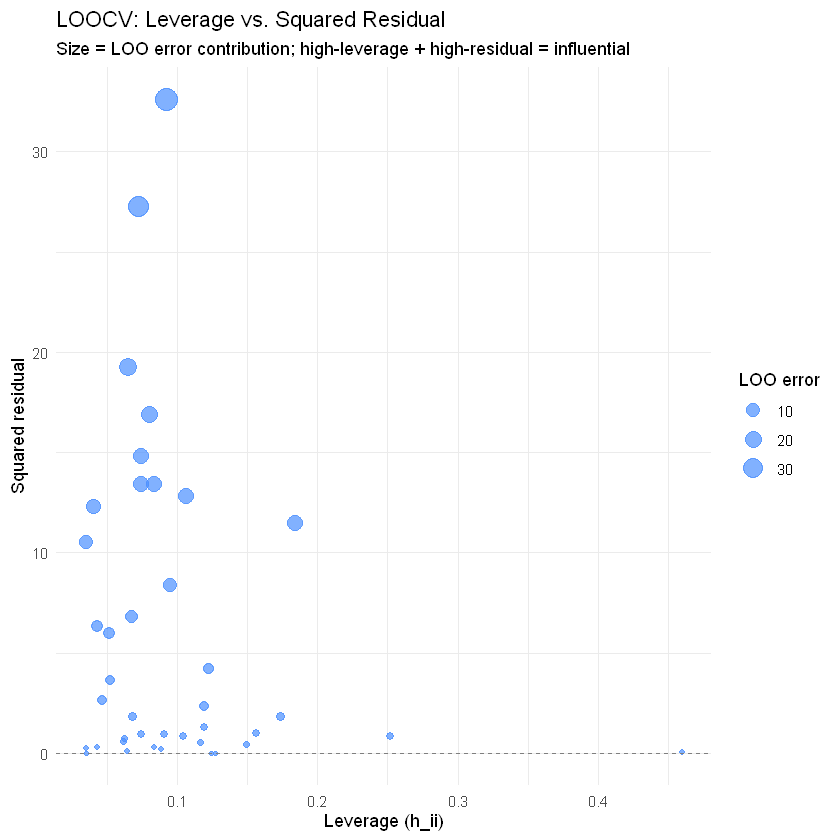

In [2]:
# ── Analytic shortcut: LOOCV MSE from leverage ────────────────────────────────
lm_fit <- lm(richness ~ nitrate + water_qual + elevation, data=loocv_data)

# Leverage values from the hat matrix diagonal
h_ii <- hatvalues(lm_fit)
e_i  <- residuals(lm_fit)

# LOOCV MSE: mean of (residual / (1 - leverage))^2
loocv_mse_analytic <- mean((e_i / (1 - h_ii))^2)
loocv_rmse_analytic <- sqrt(loocv_mse_analytic)

# Compare to brute-force LOOCV
loocv_rmse_brute <- map_dbl(seq_len(nrow(loocv_data)), function(i) {
  m   <- lm(richness ~ nitrate + water_qual + elevation,
             data=loocv_data[-i,])
  pred <- predict(m, newdata=loocv_data[i,])
  (loocv_data$richness[i] - pred)^2
}) %>% mean() %>% sqrt()

cat(sprintf("Analytic LOOCV RMSE:    %.4f\n", loocv_rmse_analytic))
cat(sprintf("Brute-force LOOCV RMSE: %.4f  (should match)\n", loocv_rmse_brute))

# ── Plot leverage vs. residual ────────────────────────────────────────────────
tibble(
  id        = seq_len(n_small),
  leverage  = h_ii,
  residual  = e_i,
  loo_error = (e_i / (1 - h_ii))^2
) %>%
  ggplot(aes(x=leverage, y=residual^2, size=loo_error)) +
  geom_point(color="#4a8fff", alpha=0.7) +
  geom_hline(yintercept=0, linetype="dashed", color="gray50") +
  labs(title="LOOCV: Leverage vs. Squared Residual",
       subtitle="Size = LOO error contribution; high-leverage + high-residual = influential",
       x="Leverage (h_ii)", y="Squared residual", size="LOO error") +
  theme_minimal()

---

## LOOCV with `rsample` (Any Model)

In [4]:
# For small datasets with non-linear models
n_class <- 50
loo_class_data <- tibble(
  nitrate    = rnorm(n_class, 3, 1.2),
  water_qual = rnorm(n_class, 6, 1.5),
  elevation  = rnorm(n_class, 200, 80),
  present    = factor(rbinom(n_class, 1,
                       plogis(-1 + 0.5 * water_qual - 0.6 * nitrate)),
                      levels = c(0, 1), labels = c("absent", "present"))
)

cat(sprintf("LOOCV resamples: %d\n", n_class))

# tune::fit_resamples() does not support LOO CV — implement manually
loo_results <- map_dfr(seq_len(n_class), function(i) {
  train_fold <- loo_class_data[-i, ]
  test_fold  <- loo_class_data[i,  ]

  fit <- glm(present ~ nitrate + water_qual + elevation,
             data   = train_fold,
             family = binomial())

  prob <- predict(fit, newdata = test_fold, type = "response")
  pred <- factor(ifelse(prob >= 0.5, "present", "absent"),
                 levels = c("absent", "present"))

  tibble(
    truth    = test_fold$present,
    estimate = pred,
    prob     = prob
  )
})

# Metrics
cat("\nLOOCV Accuracy:\n")
yardstick::accuracy(loo_results, truth = truth, estimate = estimate) %>% print()

cat("\nLOOCV ROC AUC:\n")
yardstick::roc_auc(loo_results, truth = truth, prob,
                   event_level = "second") %>% print()

LOOCV resamples: 50



LOOCV Accuracy:
# A tibble: 1 × 3
  .metric  .estimator .estimate
  <chr>    <chr>          <dbl>
1 accuracy binary          0.64

LOOCV ROC AUC:
# A tibble: 1 × 3
  .metric .estimator .estimate
  <chr>   <chr>          <dbl>
1 roc_auc binary         0.700


---

## LOOCV vs. k-Fold: When Does It Matter?

# A tibble: 5 × 4
      n loocv_rmse kfold_rmse     diff
  <dbl>      <dbl>      <dbl>    <dbl>
1    30      0.842      0.813 0.0292  
2    50      1.16       1.12  0.0390  
3   100      1.19       1.18  0.0165  
4   200      0.936      0.919 0.0173  
5   500      1.01       1.01  0.000669


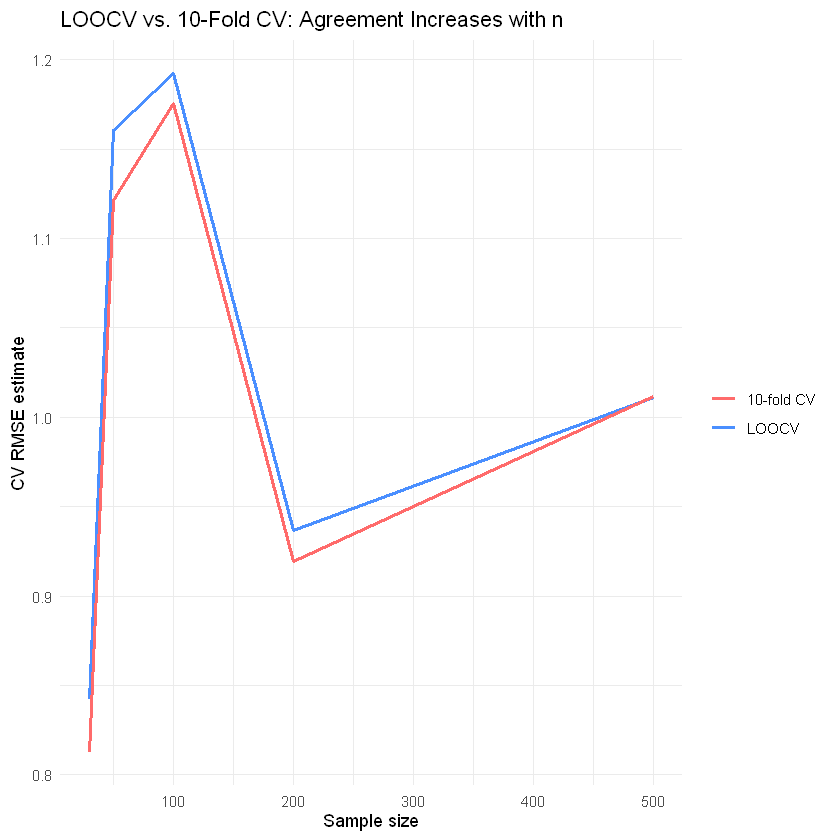

In [6]:
# Simulate multiple datasets of different sizes and compare LOOCV vs 10-fold
compare_cv <- map_dfr(c(30, 50, 100, 200, 500), function(n_sim) {
  d <- tibble(
    x = rnorm(n_sim),
    y = 3 + 2 * x + rnorm(n_sim)
  )
  spec <- linear_reg() %>% set_engine("lm")
  rec  <- recipe(y ~ x, data = d)
  wf   <- workflow() %>% add_recipe(rec) %>% add_model(spec)

  # Manual LOO CV — tune::fit_resamples() does not support loo_cv()
  loo_rmse <- map_dbl(seq_len(n_sim), function(i) {
    fit  <- lm(y ~ x, data = d[-i, ])
    pred <- predict(fit, newdata = d[i, ])
    (d$y[i] - pred)^2
  }) %>% mean() %>% sqrt()

  # 10-fold CV via tune — works fine
  kf_est <- fit_resamples(wf, vfold_cv(d, v = 10),
                          metrics = metric_set(rmse)) %>%
    collect_metrics() %>% pull(mean)

  tibble(n = n_sim, loocv_rmse = loo_rmse, kfold_rmse = kf_est,
         diff = abs(loo_rmse - kf_est))
})

print(compare_cv)
# Differences should shrink as n increases
# At small n, LOOCV is more reliable
# At large n, 10-fold is equally reliable and much faster

ggplot(compare_cv, aes(x = n)) +
  geom_line(aes(y = loocv_rmse, color = "LOOCV"),    linewidth = 1) +
  geom_line(aes(y = kfold_rmse, color = "10-fold CV"), linewidth = 1) +
  scale_color_manual(values = c(LOOCV = "#4a8fff", `10-fold CV` = "#ff6b6b")) +
  labs(title = "LOOCV vs. 10-Fold CV: Agreement Increases with n",
       x = "Sample size", y = "CV RMSE estimate", color = NULL) +
  theme_minimal()

---

## Common Pitfalls

**1. Using LOOCV for large datasets**  
LOOCV requires n model fits. For n=1000 with a random forest, this is 1000 × the cost of one fit — hours of computation. For n > 100, 10-fold repeated CV is a better trade-off between bias and variance. Reserve LOOCV for n < 50 or fast analytic models.

**2. Expecting lower LOOCV error than k-fold**  
LOOCV uses n−1 observations for training (the most data possible), so it has the lowest bias. But its error estimates are highly variable — the n estimates are correlated because they share almost identical training sets. The variance of LOOCV can actually be *higher* than 10-fold CV, even though the bias is lower.

**3. Using the analytic LOOCV shortcut for GLMs without checking assumptions**  
The leverage-based formula applies exactly to OLS. For generalised linear models (logistic, Poisson), the analytic approximation using GLM influence measures is only approximate. Use brute-force refitting or `rsample::loo_cv()` for classification problems.

**4. Interpreting LOOCV as an estimate of future individual predictions**  
LOOCV estimates generalisation to a new observation from the same population as the training data. It does not estimate performance on observations from a different distribution, time period, or geographic region.

**5. Not accounting for preprocessing in LOOCV**  
The same preprocessing leakage issue applies to LOOCV: preprocessing must be refit inside each LOO iteration. Using `workflow()` with `fit_resamples()` handles this correctly.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*